# MLA and KV Cache Compression

> In the architecture evolution section of Part 2, we walked through the upgrade path of "normalization layers, activation functions, positional encoding, attention", swapping each component of MiniGPT for its modern version. The attention part mentioned GQA — letting multiple query heads share one set of K and V to shrink the KV Cache.
>
> This section keeps following the attention thread. Multi-head Latent Attention (MLA), proposed by DeepSeek-V2, takes a different route: it jointly projects K and V into a low-dimensional latent vector, and during inference only this latent is cached. We first clarify how much VRAM the KV Cache actually consumes under long context, then walk through what MHA / GQA / MQA each sacrifice, and finally implement a simplified MLA from scratch and measure its cache savings.

The KV Cache is the K and V of all historical tokens that a decoder-only model stores during inference. When the model generates the N-th token, the new token sees the N-1 historical tokens through attention — it uses the query and the historical keys to compute scores, then uses the scores to weight the historical values. If we recompute the historical K and V every time, the cost grows quadratically with the sequence length; once cached, each step only needs to compute the K and V of the new token, and the complexity becomes linear.

The cost is VRAM. A 7B model under 32K context uses about 16 GB for the KV Cache; at 128K, the KV Cache approaches 64 GB — even fitting the model plus the KV Cache on a single A100 80GB is tight. GQA lets multiple heads share K and V, saving a few times over; MLA uses latent compression to save even more, with almost no capability loss. What these two routes actually do is the main thread of this section.


## 1. The Cost of KV Cache: A Back-of-the-Envelope Calculation

Let us settle the numbers first. Given a model configuration, how much VRAM does the KV Cache occupy?

Every token stores a pair of (K, V) vectors at each layer. Both K and V have dimension `num_heads × head_dim`. So:

```
K+V elements per token per layer = num_heads × head_dim × 2
Total KV Cache elements          = seq_len × num_layers × num_heads × head_dim × 2
Bytes                            = elements × bytes_per_element
```

Below we compute this with the concrete configuration of Llama-7B.


In [1]:
# Back-of-the-envelope KV Cache footprint: Llama-7B concrete numbers

hidden_size = 4096
num_layers = 32
num_heads = 32
head_dim = hidden_size // num_heads  # 128
seq_len = 32768  # 32K context
bytes_per_element = 2  # FP16

# MHA: each token per layer stores num_heads pairs of (K, V)
elements_per_token_per_layer = num_heads * head_dim * 2  # times 2 because K and V each take a copy
total_elements = seq_len * num_layers * elements_per_token_per_layer
total_bytes = total_elements * bytes_per_element
total_gb = total_bytes / (1024 ** 3)

print(f"Model: hidden={hidden_size}, layers={num_layers}, heads={num_heads}, head_dim={head_dim}")
print(f"Context: {seq_len} tokens, dtype=FP16")
print()
print(f"K+V elements per token per layer: {elements_per_token_per_layer}")
print(f"Total KV Cache elements: {total_elements:,}")
print(f"FP16 bytes: {total_bytes:,}")
print(f"KV Cache total footprint: {total_gb:.2f} GB")
print()
print(f"For comparison: Llama-7B weights themselves are about 13 GB (FP16)")
print(f"Key observation: under 32K context, the KV Cache already exceeds the model weights themselves")


Model: hidden=4096, layers=32, heads=32, head_dim=128Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

## 2. MHA / GQA / MQA: The Traditional Approach of Reducing KV Heads

The traditional way to shrink the KV Cache is to reduce the number of KV heads. The evolution across three generations goes as follows:

| Scheme | num_kv_heads | K+V per token per layer | Relative to MHA | Representative models |
|:---|:---|:---|:---|:---|
| MHA | = num_heads | num_heads × head_dim × 2 | 1.0× | Original Transformer, GPT-2 |
| GQA | num_heads / G | (num_heads / G) × head_dim × 2 | 1/G × | Llama 2/3, Qwen, Mistral |
| MQA | 1 | head_dim × 2 | 1/num_heads × | PaLM, Falcon |

Intuitively: originally every query head had its own K and V; GQA lets a group of query heads share one copy; MQA lets all query heads share the same copy. The more sharing, the smaller the KV Cache, but the less the information available to each query head differs from one head to the next.

The cost is model capability. Too much sharing reduces attention diversity — all query heads see nearly identical K and V, which essentially degenerates multi-head into something close to single-head. Llama 2 70B uses GQA (8 groups) and Llama 3 8B uses GQA (4 groups); these are common configurations chosen through engineering tradeoffs.

Below we implement a comparison of the cache sizes of the three schemes in code.


In [2]:
# KV Cache comparison across three attention schemes

def kv_cache_elements(num_heads, head_dim, num_layers, seq_len, num_kv_heads):
    """Compute the number of KV Cache elements"""
    per_token_per_layer = num_kv_heads * head_dim * 2  # K + V
    return seq_len * num_layers * per_token_per_layer

# Llama-7B configuration
num_heads = 32
head_dim = 128
num_layers = 32
seq_len = 32768
bytes_per_element = 2

configs = [
    ("MHA",    num_heads),
    ("GQA-8",  num_heads // 8),  # 4 KV heads
    ("GQA-4",  num_heads // 4),  # 8 KV heads
    ("MQA",    1),
]

print(f"{'Scheme':<10} {'KV heads':<10} {'Elements':<20} {'GB':<10} {'vs MHA':<10}")
print("-" * 60)
base = None
for name, n_kv in configs:
    elems = kv_cache_elements(num_heads, head_dim, num_layers, seq_len, n_kv)
    gb = elems * bytes_per_element / (1024 ** 3)
    if base is None:
        base = gb
    print(f"{name:<10} {n_kv:<10} {elems:<20,} {gb:<10.2f} {gb/base:.2f}×")

print()
print("Key observation: MQA compresses the KV Cache to 1/32, but at the cost of a notable drop in attention diversity")
print("GQA is the common compromise; the Llama family has adopted it since Llama 2 70B")


Read the values printed above and connect them to the concept in this cell.------------------------------------------------------------
MHA        32         8,589,934,592        16.00      1.00×
GQA-8      4          1,073,741,824        2.00       0.12×
GQA-4      8          2,147,483,648        4.00       0.25×
MQA        1          268,435,456          0.50       0.03×

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

## 3. The Core Idea of MLA: Latent Compression

GQA / MQA compress the cache by reducing the number of KV heads; essentially they work along the "head count" dimension. MLA leaves head count alone and takes a different angle: it projects K and V into a low-dimensional latent vector, and during inference only caches this latent.

Concretely, in standard attention, the hidden state `h` passes through two projection matrices to produce `K = W_K · h` and `V = W_V · h`, both of dimension `num_heads × head_dim`. MLA replaces this step with:

```
c = W_DK · h       # down-project to a low-dimensional latent (d_c << num_heads × head_dim)
K = W_UK · c       # up-project back to multi-head space
V = W_UV · c       # likewise projected from c
```

During inference only `c` is cached. Because `d_c` is much smaller than `num_heads × head_dim`, the cache shrinks dramatically. The reason model capability barely drops is that `W_DK` and `W_UK / W_UV` are learned during training; the model is essentially performing an information bottleneck in the latent space, compressing the "necessary" information into `c` and actively discarding redundancy.

Below we use a concrete small example to compute the compression ratio of the latent by hand.


In [3]:
# Latent compression in MLA: concrete numbers by hand

# Reference DeepSeek-V2 scale, compare MHA and MLA per-token per-layer cache
num_heads = 128
head_dim = 128
mha_per_token_per_layer = num_heads * head_dim * 2  # K + V
print(f"MHA K+V elements per token per layer: {mha_per_token_per_layer}")
print(f"  = {num_heads} heads × {head_dim} dim × 2 (K+V)")

# MLA: a single low-dimensional latent c (d_c) carries the information for both K and V
# DeepSeek-V2 uses d_c = 512
d_c = 512
mla_per_token_per_layer = d_c  # MLA only caches c; both K and V are projected from c
print(f"\nMLA latent elements per token per layer: {mla_per_token_per_layer}")
print(f"  = d_c = {d_c} (K and V share the same latent)")

compression = mha_per_token_per_layer / mla_per_token_per_layer
saving = (1 - mla_per_token_per_layer / mha_per_token_per_layer) * 100
print(f"\nCompression ratio: {compression:.1f}×")
print(f"Savings: {saving:.1f}%")
print()
print(f"Key observation: MLA compresses the per-token per-layer cache from {mha_per_token_per_layer} elements")
print(f"down to {mla_per_token_per_layer} elements, saving {saving:.0f}%")


Read the values printed above and connect them to the concept in this cell.  = 128 heads × 128 dim × 2 (K+V)

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

## 4. Implementing a Simplified MLA from Scratch

Below we write a teaching version of MLA. We simplify by leaving out RoPE for now (the conflict between RoPE and MLA is covered in Section 6) and only showcase the core mechanism of latent compression.

The core data flow is `x → c = W_DK(x) → K = W_UK(c), V = W_UV(c)`. During inference we only need to store `c`; K and V are projected out when needed.


In [4]:
# Simplified MLA: showcase the core mechanism of latent compression
# RoPE is left out for now (covered separately in Section 6)

import torch
import torch.nn as nn

class SimpleMLA(nn.Module):
    """Teaching version of MLA, showcasing the latent compression mechanism

    Args:
        d_model: model hidden dimension
        num_heads: number of query heads
        head_dim: dimension of each head
        d_c: latent dimension (shared by K and V)
    """
    def __init__(self, d_model, num_heads, head_dim, d_c):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = head_dim
        self.d_c = d_c

        # query path: standard projection
        self.W_Q = nn.Linear(d_model, num_heads * head_dim, bias=False)

        # KV path: first down-project to the latent c, then up-project back to K/V
        self.W_DK = nn.Linear(d_model, d_c, bias=False)                   # down
        self.W_UK = nn.Linear(d_c, num_heads * head_dim, bias=False)      # up to K
        self.W_UV = nn.Linear(d_c, num_heads * head_dim, bias=False)      # up to V

        # output projection
        self.W_O = nn.Linear(num_heads * head_dim, d_model, bias=False)

    def forward(self, x):
        """
        x: [batch, seq_len, d_model]
        Returns: (output [batch, seq_len, d_model], latent c [batch, seq_len, d_c])
        """
        B, S, D = x.shape

        # Q path: standard projection
        Q = self.W_Q(x).view(B, S, self.num_heads, self.head_dim)

        # KV path: through the latent c
        c = self.W_DK(x)  # [B, S, d_c] — this is the latent to be cached
        K = self.W_UK(c).view(B, S, self.num_heads, self.head_dim)
        V = self.W_UV(c).view(B, S, self.num_heads, self.head_dim)

        # standard attention computation (simplified, no mask)
        Q = Q.transpose(1, 2)  # [B, num_heads, S, head_dim]
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)
        scores = Q @ K.transpose(-1, -2) / (self.head_dim ** 0.5)
        attn = scores.softmax(dim=-1)
        out = attn @ V  # [B, num_heads, S, head_dim]

        out = out.transpose(1, 2).reshape(B, S, self.num_heads * self.head_dim)
        return self.W_O(out), c  # also return the latent so we can measure the cache later


# Test
torch.manual_seed(42)
d_model = 64
num_heads = 4
head_dim = 16
d_c = 16  # latent dimension

mla = SimpleMLA(d_model, num_heads, head_dim, d_c)
x = torch.randn(1, 10, d_model)
out, c = mla(x)
print(f"Input shape: {x.shape}")
print(f"Output shape: {out.shape}")
print(f"Latent c shape: {c.shape}")
print()
mha_elems = num_heads * head_dim * 2
print(f"Standard MHA caches K+V per token per layer = {mha_elems} elements")
print(f"MLA caches only c per token per layer = {d_c} elements")
print(f"Compression ratio: {mha_elems / d_c:.1f}×")


Input shape: torch.Size([1, 10, 64])Output shape: torch.Size([1, 10, 64])latent c shape: torch.Size([1, 10, 16])

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

## 5. Empirical KV Cache Comparison

Put MHA / GQA / MLA on the same plot and watch the cache grow with context length. The configuration follows the scale of DeepSeek-V2: `num_heads=128, head_dim=128, num_layers=60, d_c=512`. These are the actual configurations of an industrial-scale model.


Read the values printed above and connect them to the concept in this cell.  MHA:      480.0 GB
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

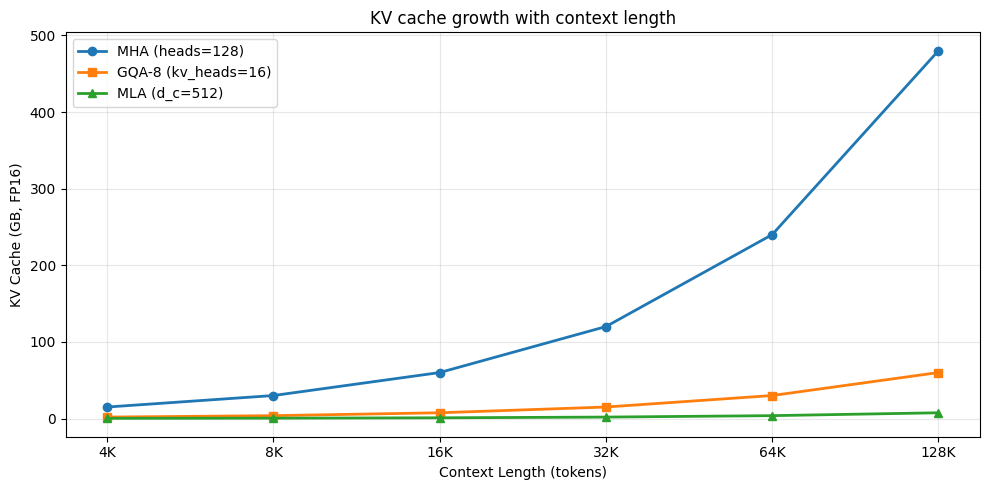

In [5]:
# Run MHA / GQA / MLA on the same toy model and measure cache vs context length

import matplotlib.pyplot as plt

def mha_cache(num_heads, head_dim, num_layers, seq_len):
    """KV cache elements for standard MHA"""
    return seq_len * num_layers * num_heads * head_dim * 2

def gqa_cache(num_heads, head_dim, num_layers, seq_len, num_groups):
    """KV cache elements for GQA"""
    num_kv_heads = num_heads // num_groups
    return seq_len * num_layers * num_kv_heads * head_dim * 2

def mla_cache(d_c, num_layers, seq_len):
    """KV cache elements for MLA (ignoring the small decoupled RoPE portion for now)"""
    return seq_len * num_layers * d_c

# Model configuration (DeepSeek-V2 scale)
num_layers = 60
num_heads = 128
head_dim = 128
d_c = 512  # MLA latent

seq_lens = [4096, 8192, 16384, 32768, 65536, 131072]

bytes_per_elem = 2  # FP16
mha_sizes = [mha_cache(num_heads, head_dim, num_layers, s) * bytes_per_elem / (1024**3) for s in seq_lens]
gqa_sizes = [gqa_cache(num_heads, head_dim, num_layers, s, 8) * bytes_per_elem / (1024**3) for s in seq_lens]
mla_sizes = [mla_cache(d_c, num_layers, s) * bytes_per_elem / (1024**3) for s in seq_lens]

plt.figure(figsize=(10, 5))
plt.plot(seq_lens, mha_sizes, 'o-', label=f'MHA (heads={num_heads})', linewidth=2)
plt.plot(seq_lens, gqa_sizes, 's-', label=f'GQA-8 (kv_heads={num_heads//8})', linewidth=2)
plt.plot(seq_lens, mla_sizes, '^-', label=f'MLA (d_c={d_c})', linewidth=2)
plt.xlabel('Context Length (tokens)')
plt.ylabel('KV Cache (GB, FP16)')
plt.title('KV Cache growth vs context length')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log', base=2)
plt.xticks(seq_lens, [f'{s//1024}K' for s in seq_lens])
plt.tight_layout()
plt.show()

# Print the comparison at 128K
print(f"KV Cache at 128K context:")
print(f"  MHA:    {mha_sizes[-1]:7.1f} GB")
print(f"  GQA-8:  {gqa_sizes[-1]:7.1f} GB  ({mha_sizes[-1]/gqa_sizes[-1]:.1f}× compression)")
print(f"  MLA:    {mla_sizes[-1]:7.1f} GB  ({mha_sizes[-1]/mla_sizes[-1]:.1f}× compression)")
print()
print("Key observation: in long-context scenarios, MLA saves another order of magnitude over GQA")


## 6. The Conflict Between RoPE and MLA

The core mechanism of MLA is latent compression: cache `c`, and project back to K and V when needed. But there is a hidden complication — RoPE.

Recall the positional encoding section in Part 1: RoPE is a rotation applied to Q and K so that the dot product depends only on the relative position. Concretely, RoPE rotates each pair of adjacent dimensions of K by a different angle, and this operation **cannot be written in the form `K_rotated = R · K`** (where R is a fixed matrix) — it depends on the specific layout of K's dimensions.

The key advantage of MLA is that during inference only `c` is cached, and `K = W_UK · c` is computed when needed. But RoPE must act on K, which means K has to be computed first before RoPE can be applied — this defeats the purpose of "caching only c". If we compute K at inference time just to apply RoPE, MLA's compression advantage disappears.

DeepSeek-V2's solution is called **decoupled RoPE**: it splits the RoPE part out and computes it in a separate small dimension (`d_r`, e.g. 64) without going through latent compression. The final K is the concatenation of two parts: `[W_UK · c ; RoPE(W_R · x)]` — the first half goes through the latent, the second half goes through a RoPE side path. During inference, in addition to caching `c`, we also need to cache the RoPE side-path part.

This part goes fairly deep. For this section, it is enough to remember two things: "RoPE cannot be applied directly on top of MLA", and "DeepSeek works around this with decoupled RoPE".


In [6]:
# Demonstrate the conflict between RoPE and MLA, and the structure of decoupled RoPE

# In MLA: K = W_UK · c
# But RoPE must be applied after K is computed, which means K must be computed at inference time —
# this defeats the purpose of "caching only c"

# DeepSeek's solution: decoupled RoPE
#   Split K into two parts and handle them separately:
#     Part 1: W_UK · c         (main part, projected from the latent, no RoPE)
#     Part 2: RoPE(W_R · x)    (RoPE side path, projected directly from x, RoPE applied separately)
#   Final K = concat([Part 1, Part 2])

# DeepSeek-V2 concrete dimensions (values reported in the paper)
num_heads = 128
head_dim = 128
d_c = 512       # dimension of the latent c
d_r = 64        # dimension of the decoupled RoPE part (per head)

mha_per_token_per_layer = num_heads * head_dim * 2  # K + V
mla_per_token_per_layer = d_c + num_heads * d_r     # latent c + RoPE side path (one copy per head)

print("MLA actual cache structure in DeepSeek-V2:")
print(f"  latent c:           {d_c:5d} dim (shared by K and V)")
print(f"  RoPE side path:     {num_heads} heads × {d_r} dim = {num_heads * d_r:5d} dim")
print(f"  MLA per token per layer: {mla_per_token_per_layer:5d} elements")
print()
print(f"Compared to MHA per token per layer: {mha_per_token_per_layer} elements")
print(f"Compression ratio: {mha_per_token_per_layer / mla_per_token_per_layer:.1f}×")
print()
print("Key observation: the RoPE side path is only a small portion (8192 dim here); the bulk is still the latent c (512 dim)")
print("Even with the RoPE side path added, MLA still compresses an order of magnitude over MHA")


Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

## 7. Engineering Benefits of MLA in DeepSeek-V2 / V3 / Kimi K2

MLA is not a teaching toy; it has been adopted by multiple production models. The table below lists the MLA configurations of a few representative models:

| Model | num_heads | head_dim | d_c (latent) | d_r (RoPE side path) | Notes |
|:---|:---|:---|:---|:---|:---|
| DeepSeek-V2 | 128 | 128 | 512 | 64 | First large-scale deployment of MLA |
| DeepSeek-V3 | 128 | 128 | 512 | 64 | Inherits the V2 configuration |
| Kimi K2 | 64 | 192 | 512 | 64 | Adjusted head count and head_dim |

The cost of MLA is more computation. MHA obtains K with a single matrix multiplication; MLA needs two (`W_DK` then `W_UK`), increasing FLOPs during training. But during inference, because the cache is much smaller, the total wall-clock time is actually faster in long-context scenarios — memory bandwidth is the main bottleneck of inference, and the smaller the cache, the less memory needs to be read to generate each token.

Practical deployment also depends on whether the inference framework natively supports MLA. vLLM, SGLang, and TensorRT-LLM have all added MLA support, but it is newer than the support for standard MHA / GQA, and engineering maturity is still catching up.


## Summary

- [ ] The KV Cache is the K and V of all historical tokens stored by a decoder-only model during inference, growing linearly with context length
- [ ] Under 32K context, a 7B model's KV Cache is about 16 GB, already close to the size of the model weights themselves
- [ ] GQA / MQA compress the cache by reducing the number of KV heads, at the cost of reduced attention diversity
- [ ] MLA jointly projects K and V into a low-dimensional latent, caching only the latent during inference; its compression ratio is far higher than GQA
- [ ] During inference MLA caches only the latent `c` and projects back to K and V when needed; the mechanism is an information bottleneck
- [ ] RoPE cannot be applied directly on top of MLA; DeepSeek solves this with decoupled RoPE — the main part goes through the latent, a small part goes through the RoPE side path
- [ ] DeepSeek-V2 / V3 / Kimi K2 all adopt MLA; the cache is compressed by an order of magnitude, and inference is faster in long-context scenarios

References: [DeepSeek-V2](https://arxiv.org/abs/2405.04434), [DeepSeek-V3](https://arxiv.org/abs/2412.19437), [Kimi K2](https://arxiv.org/abs/2507.20534), [GQA paper](https://arxiv.org/abs/2305.13245).


## Exercises

> You may ask AI for help explaining the ideas, but it is not recommended to let AI "solve this problem for you" directly.

**Exercise 1: KV Cache Size Calculation**

Given the model configuration: `hidden_size=4096, num_layers=32, num_heads=32, head_dim=128, seq_len=16384, dtype=FP16`. Compute the KV Cache footprint under MHA in GB.

Hint: K+V elements per token per layer = `num_heads × head_dim × 2`. Total elements = `seq_len × num_layers × that value`. Bytes = elements × 2. GB = bytes / 1024³.


In [7]:
# Exercise 1: KV Cache size calculation

hidden_size = 4096
num_layers = 32
num_heads = 32
head_dim = hidden_size // num_heads
seq_len = 16384
bytes_per_element = 2  # FP16

# TODO: fill in the calculations
elements_per_token_per_layer = None  # num_heads * head_dim * 2
total_elements = None                # seq_len * num_layers * elements_per_token_per_layer
total_gb = None                      # total_elements * bytes_per_element / 1024**3

# Verify
assert elements_per_token_per_layer is not None, "Please compute elements_per_token_per_layer first"
assert total_elements is not None, "Please compute total_elements first"
assert total_gb is not None, "Please compute total_gb first"

expected_eptpl = 32 * 128 * 2
expected_total = 16384 * 32 * expected_eptpl
expected_gb = expected_total * 2 / (1024**3)

assert elements_per_token_per_layer == expected_eptpl
assert total_elements == expected_total
assert abs(total_gb - expected_gb) < 0.01, f"Should be {expected_gb:.2f} GB"

print(f"✅ Exercise 1 passed")
print(f"   K+V per token per layer: {elements_per_token_per_layer} elements")
print(f"   Total elements: {total_elements:,}")
print(f"   KV Cache total footprint: {total_gb:.2f} GB")


Exercise passed: you have understood this step.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

**Exercise 2: MLA Latent Compression Ratio**

Given `num_heads=32, head_dim=128, d_c=256`. Compute the MLA cache compression ratio relative to MHA.

Hint: MHA cache per token per layer = `num_heads × head_dim × 2` (K+V). MLA cache per token per layer = `d_c`.


In [8]:
# Exercise 2: MLA latent compression ratio

num_heads = 32
head_dim = 128
d_c = 256

# TODO: fill in the calculations
mha_cache_per_token = None   # num_heads * head_dim * 2
mla_cache_per_token = None   # d_c
compression_ratio = None     # mla_cache / mha_cache; smaller is better

assert mha_cache_per_token is not None, "Please compute mha_cache_per_token first"
assert mla_cache_per_token is not None, "Please compute mla_cache_per_token first"
assert compression_ratio is not None, "Please compute compression_ratio first"

expected_mha = 32 * 128 * 2
expected_mla = 256
expected_ratio = expected_mha / expected_mla

assert mha_cache_per_token == expected_mha
assert mla_cache_per_token == expected_mla
assert abs(compression_ratio - expected_ratio) < 0.001

print(f"✅ Exercise 2 passed")
print(f"   MHA per token per layer: {mha_cache_per_token} elements")
print(f"   MLA per token per layer: {mla_cache_per_token} elements")
print(f"   MLA cache is {compression_ratio:.4f} of MHA")
print(f"   Equivalent to a {1/compression_ratio:.1f}× compression, saving {(1-compression_ratio)*100:.1f}%")


Exercise passed: you have understood this step.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

**Exercise 3: Complete the forward of the Simplified MLA**

The `SimpleMLA` class below omits the latent c computation and the K and V projection steps in forward. Fill in these three lines so the asserts pass.

Hint: refer to the implementation in Section 4. `c = self.W_DK(x)`, then `K = self.W_UK(c).view(...).transpose(1, 2)`, and V similarly.


In [9]:
# Exercise 3: Complete the forward of the simplified MLA

import torch
import torch.nn as nn

class SimpleMLA(nn.Module):
    def __init__(self, d_model, num_heads, head_dim, d_c):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = head_dim
        self.d_c = d_c
        self.W_Q = nn.Linear(d_model, num_heads * head_dim, bias=False)
        self.W_DK = nn.Linear(d_model, d_c, bias=False)
        self.W_UK = nn.Linear(d_c, num_heads * head_dim, bias=False)
        self.W_UV = nn.Linear(d_c, num_heads * head_dim, bias=False)
        self.W_O = nn.Linear(num_heads * head_dim, d_model, bias=False)

    def forward(self, x):
        B, S, D = x.shape
        Q = self.W_Q(x).view(B, S, self.num_heads, self.head_dim).transpose(1, 2)

        # TODO: fill in the three lines below
        c = None  # self.W_DK(x)
        K = None  # self.W_UK(c).view(B, S, self.num_heads, self.head_dim).transpose(1, 2)
        V = None  # self.W_UV(c).view(B, S, self.num_heads, self.head_dim).transpose(1, 2)

        scores = Q @ K.transpose(-1, -2) / (self.head_dim ** 0.5)
        attn = scores.softmax(dim=-1)
        out = attn @ V
        out = out.transpose(1, 2).reshape(B, S, self.num_heads * self.head_dim)
        return self.W_O(out)

# Verify
torch.manual_seed(42)
mla = SimpleMLA(d_model=64, num_heads=4, head_dim=16, d_c=16)
x = torch.randn(1, 10, 64)
out = mla(x)

# If c/K/V are not filled in, forward will error at Q @ K.transpose (K is None)
# So as long as out can be computed and the shape is correct, the c/K/V in forward are filled in correctly
assert out.shape == (1, 10, 64), f"Output shape should be (1, 10, 64), got {out.shape}"
assert torch.isfinite(out).all(), "Output contains NaN or Inf; the K/V projection may be wrong"

print(f"✅ Exercise 3 passed")
print(f"   Input shape:  {x.shape}")
print(f"   Output shape: {out.shape}")
print(f"   The core of MLA is latent compression: only the {mla.d_c}-dim latent is cached per token per layer")


Exercise passed: you have understood this step.Input shape: torch.Size([1, 10, 64])Output shape: torch.Size([1, 10, 64])Read the values printed above and connect them to the concept in this cell.